# Analytics Final Project on Movie Ratings

# Question and Background Information

## Import Packages

In [103]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

## Load Data and Get Basic Dataset Stats

In [104]:
# Load movie dataset
df = pd.read_csv("movies_dataset.csv")

# Preview the dataset
print(df.head())

                                             name rating      genre  year  \
0                                     The Shining      R      Drama  1980   
1                                 The Blue Lagoon      R  Adventure  1980   
2  Star Wars: Episode V - The Empire Strikes Back     PG     Action  1980   
3                                       Airplane!     PG     Comedy  1980   
4                                      Caddyshack      R     Comedy  1980   

                        released  score      votes         director  \
0  June 13, 1980 (United States)    8.4   927000.0  Stanley Kubrick   
1   July 2, 1980 (United States)    5.8    65000.0   Randal Kleiser   
2  June 20, 1980 (United States)    8.7  1200000.0   Irvin Kershner   
3   July 2, 1980 (United States)    7.7   221000.0     Jim Abrahams   
4  July 25, 1980 (United States)    7.3   108000.0     Harold Ramis   

                    writer            star         country      budget  \
0             Stephen King  Jack Nic

In [105]:
# Print the columns and shape of the dataset
print(df.info(), "\n")
print("\nUpdated shape:", df.shape)

<class 'pandas.DataFrame'>
RangeIndex: 7668 entries, 0 to 7667
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      7668 non-null   str    
 1   rating    7591 non-null   str    
 2   genre     7668 non-null   str    
 3   year      7668 non-null   int64  
 4   released  7666 non-null   str    
 5   score     7665 non-null   float64
 6   votes     7665 non-null   float64
 7   director  7668 non-null   str    
 8   writer    7665 non-null   str    
 9   star      7667 non-null   str    
 10  country   7665 non-null   str    
 11  budget    5497 non-null   float64
 12  gross     7479 non-null   float64
 13  company   7651 non-null   str    
 14  runtime   7664 non-null   float64
dtypes: float64(5), int64(1), str(9)
memory usage: 898.7 KB
None 


Updated shape: (7668, 15)


In [106]:
print(df.describe())

              year        score         votes        budget         gross  \
count  7668.000000  7665.000000  7.665000e+03  5.497000e+03  7.479000e+03   
mean   2000.405451     6.390411  8.810850e+04  3.558988e+07  7.850054e+07   
std      11.153508     0.968842  1.633238e+05  4.145730e+07  1.657251e+08   
min    1980.000000     1.900000  7.000000e+00  3.000000e+03  3.090000e+02   
25%    1991.000000     5.800000  9.100000e+03  1.000000e+07  4.532056e+06   
50%    2000.000000     6.500000  3.300000e+04  2.050000e+07  2.020576e+07   
75%    2010.000000     7.100000  9.300000e+04  4.500000e+07  7.601669e+07   
max    2020.000000     9.300000  2.400000e+06  3.560000e+08  2.847246e+09   

           runtime  
count  7664.000000  
mean    107.261613  
std      18.581247  
min      55.000000  
25%      95.000000  
50%     104.000000  
75%     116.000000  
max     366.000000  


In [107]:
# Create a copy so we don't modify the original dataframe
movies = df.copy()

In [108]:
# Remove rows where the movie score is missing
movies = movies.dropna(subset=["score"])

# Create binary target:
# 1 = high-rated movie (score >= 7), 0 = lower-rated
movies["high_rating"] = (movies["score"] >= 7).astype(int)

# Check distribution of the target variable
print(movies["high_rating"].value_counts())
print()
print(movies["high_rating"].value_counts(normalize=True))

high_rating
0    5399
1    2266
Name: count, dtype: int64

high_rating
0    0.704371
1    0.295629
Name: proportion, dtype: float64


In [109]:
# Remove duplicate rows to avoid bias in training
movies = movies.drop_duplicates()

# Check missing values in each column
print(movies.isnull().sum())

name              0
rating           75
genre             0
year              0
released          2
score             0
votes             0
director          0
writer            3
star              1
country           3
budget         2171
gross           186
company          15
runtime           4
high_rating       0
dtype: int64


In [110]:
# Drop rows with missing values in selected columns
movies = movies.dropna(subset=[
    "rating",
    "writer",
    "star",
    "country",
    "company",
    "runtime",
    "budget",
    "gross"
])

## Conduct EDA

In [111]:
# Check remaining missing values
print(movies.info())

# Print updated shape to see how many rows remain
print("\nUpdated shape:", movies.shape)

<class 'pandas.DataFrame'>
Index: 5421 entries, 0 to 7652
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   name         5421 non-null   str    
 1   rating       5421 non-null   str    
 2   genre        5421 non-null   str    
 3   year         5421 non-null   int64  
 4   released     5421 non-null   str    
 5   score        5421 non-null   float64
 6   votes        5421 non-null   float64
 7   director     5421 non-null   str    
 8   writer       5421 non-null   str    
 9   star         5421 non-null   str    
 10  country      5421 non-null   str    
 11  budget       5421 non-null   float64
 12  gross        5421 non-null   float64
 13  company      5421 non-null   str    
 14  runtime      5421 non-null   float64
 15  high_rating  5421 non-null   int64  
dtypes: float64(5), int64(2), str(9)
memory usage: 720.0 KB
None

Updated shape: (5421, 16)


In [112]:
# Summary statistics for key numeric variables
print(movies.describe())

              year        score         votes        budget         gross  \
count  5421.000000  5421.000000  5.421000e+03  5.421000e+03  5.421000e+03   
mean   2001.661317     6.392455  1.150661e+05  3.600917e+07  1.032297e+08   
std      10.540908     0.962730  1.844073e+05  4.157337e+07  1.873027e+08   
min    1980.000000     1.900000  1.950000e+02  6.000000e+03  3.090000e+02   
25%    1993.000000     5.800000  1.900000e+04  1.000000e+07  1.073640e+07   
50%    2002.000000     6.500000  5.200000e+04  2.180000e+07  3.686941e+07   
75%    2011.000000     7.100000  1.290000e+05  4.500000e+07  1.124625e+08   
max    2020.000000     9.300000  2.400000e+06  3.560000e+08  2.847246e+09   

           runtime  high_rating  
count  5421.000000  5421.000000  
mean    108.152739     0.289246  
std      18.115698     0.453454  
min      63.000000     0.000000  
25%      95.000000     0.000000  
50%     105.000000     0.000000  
75%     118.000000     1.000000  
max     271.000000     1.000000  


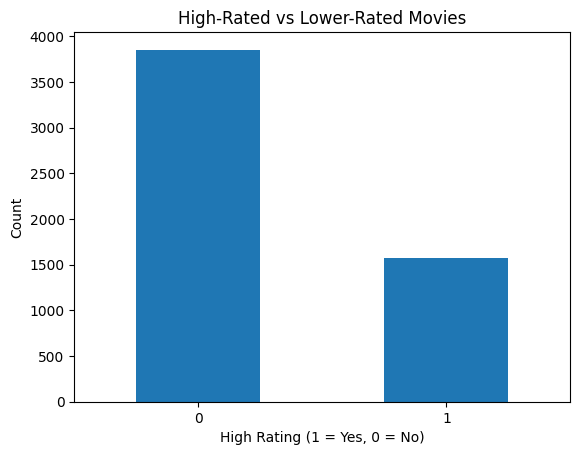

In [113]:
# Visualize how many movies are high-rated vs lower-rated
movies["high_rating"].value_counts().plot(kind="bar")
plt.title("High-Rated vs Lower-Rated Movies")
plt.xlabel("High Rating (1 = Yes, 0 = No)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

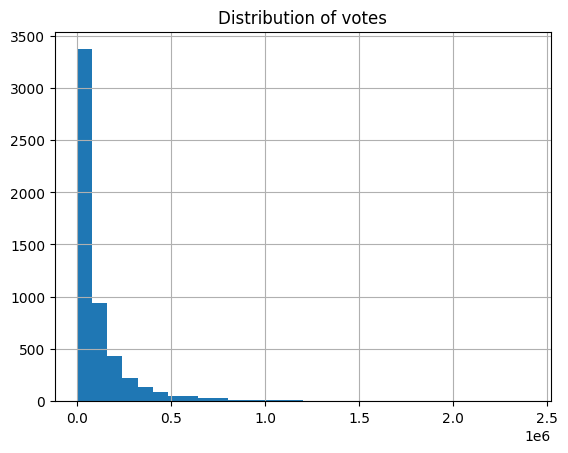

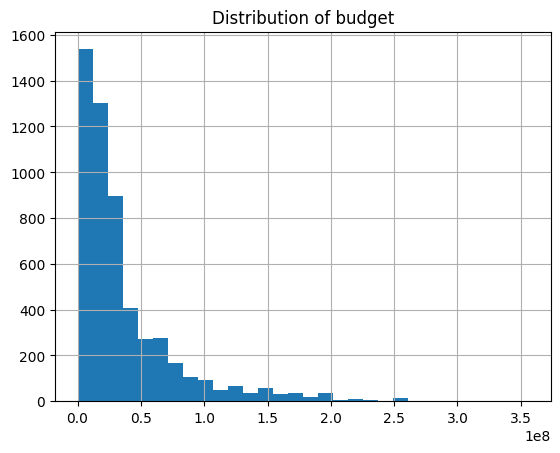

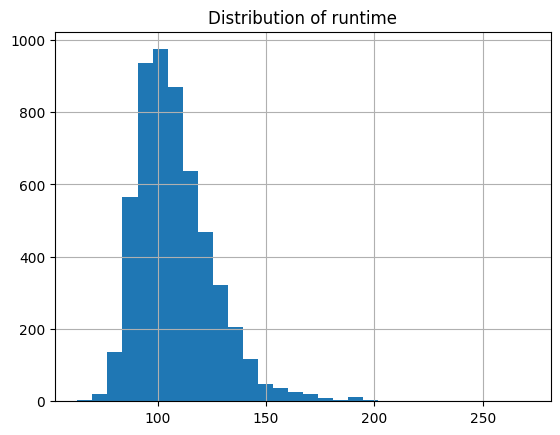

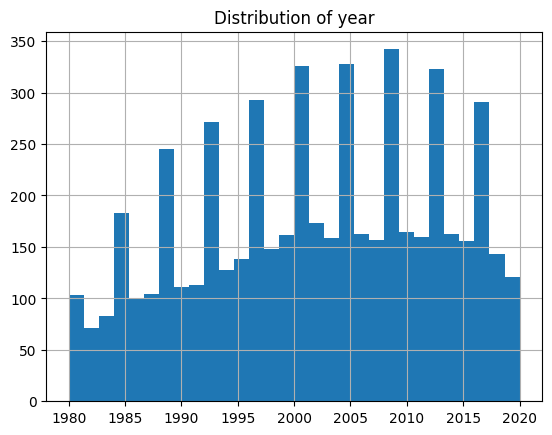

In [114]:
# Plot distributions of important numeric variables
for col in ["votes", "budget", "runtime", "year"]:
    movies[col].hist(bins=30)
    plt.title(f"Distribution of {col}")
    plt.show()

In [115]:
# Compare average values of features between classes
for col in ["votes", "budget", "runtime", "year"]:
    print(f"\nAverage {col} by high_rating:")
    print(movies.groupby("high_rating")[col].mean())


Average votes by high_rating:
high_rating
0     65506.581884
1    236847.338010
Name: votes, dtype: float64

Average budget by high_rating:
high_rating
0    3.518441e+07
1    3.803582e+07
Name: budget, dtype: float64

Average runtime by high_rating:
high_rating
0    104.291461
1    117.640944
Name: runtime, dtype: float64

Average year by high_rating:
high_rating
0    2001.391124
1    2002.325255
Name: year, dtype: float64


In [116]:
# Show most common genres
print("Top genres:")
print(movies["genre"].value_counts().head(10))

Top genres:
genre
Comedy       1496
Action       1415
Drama         863
Crime         399
Adventure     327
Biography     311
Animation     277
Horror        251
Fantasy        41
Mystery        17
Name: count, dtype: int64


**EDA Insights**: 
Based on the visualizations above, we can identify several relationships that are critical for our analysis. Higher-rated movies tend to receive significantly more votes and have longer runtimes than their lower-rated counterparts. Budget distributions also show some variations, suggesting these numerical factors play a key role in movie reception. Furthermore, certain genres (like Drama, Action, and Comedy) dominate the dataset, highlighting important categorical predictors. Together, these initial statistics inform our choice of features for predicting movie ratings.

## Feature Selection

In [117]:
# Select reasonable set of features for prediction
# These include both numeric and categorical variables
features = [
    "rating",    # MPAA rating (PG, R, etc.)
    "genre",
    "year",
    "votes",
    "director",
    "star",
    "country",
    "budget",
    "company",
    "runtime"
]

# Define input features (X) and target (y)
X = movies[features]
y = movies["high_rating"]

# Print selected features
print("Features being used:")
print(features)

Features being used:
['rating', 'genre', 'year', 'votes', 'director', 'star', 'country', 'budget', 'company', 'runtime']


## Train/Test Split

In [118]:
# Split data into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y  # keeps class balance consistent
)

print(X_train.shape)
print(X_test.shape)

(4336, 10)
(1085, 10)


## Preprocessing Pipeline

In [119]:
# Identify numeric and categorical columns automatically
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "string"]
).columns.tolist()

# Since missing values were already removed during cleaning,
# numeric columns can pass through unchanged.
# Categorical columns need one-hot encoding for the model.
preprocessor = ColumnTransformer([
    ("num", "passthrough", numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

# Print feature groups for verification
print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['year', 'votes', 'budget', 'runtime']

Categorical features:
['rating', 'genre', 'director', 'star', 'country', 'company']


## Methods & Evaluation

### Model 1: Decision Tree

#### Training/Tuning Phase

In [120]:
# Create a pipeline with preprocessing + Decision Tree model
dt_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(max_depth=3, random_state=42))
])

# Train the model on the training data
dt_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

#### Evaluation of model 1

### Model 2: Random Forest

#### Training/Tuning Phase

#### Evaluation of model 2

### Model 3: Logistic Regression

#### Training/Tuning Phase

#### Evaluation of model 3

## Model Comparison

## Conclusions

## Team contribution (tentative plan)

- Data Engineer: Michelle and Will
- Researcher: Nelson
- Model Builder: Michelle and Will
- Red Team / Final Reviewer: Michelle, Will, and Nelson